In [1]:
import os
os.chdir(r'C:\Users\Muhammad Luqman\Desktop\OPEN_ENDED_LAB_21JZELE0444_LUQMAN')

In [2]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, explained_variance_score, r2_score
from timeseires.utils.to_split import to_split
from timeseires.utils.multivariate_multi_step import multivariate_multi_step
from timeseires.utils.multivariate_single_step import multivariate_single_step
from timeseires.utils.univariate_multi_step import univariate_multi_step
from timeseires.utils.univariate_single_step import univariate_single_step
from timeseires.utils.CosineAnnealingLRS import CosineAnnealingLRS
from timeseires.callbacks.EpochCheckpoint import EpochCheckpoint
from tensorflow.keras.callbacks import ModelCheckpoint
from timeseires.callbacks.TrainingMonitor import TrainingMonitor
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import LSTM, Bidirectional, Add
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv1D,TimeDistributed
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten,MaxPooling1D,Concatenate,AveragePooling1D, GlobalMaxPooling1D, Input
from tensorflow.keras.models import Sequential,Model
import pandas as pd
import time, pickle
import numpy as np
import tensorflow.keras.backend as K
import tensorflow
from tensorflow.keras.layers import Input, Reshape, Lambda
from tensorflow.keras.layers import Layer, Flatten, LeakyReLU, concatenate, Dense
from tensorflow.keras.regularizers import l2
import glob
import h5py
import matplotlib.pyplot as plt
from keras.callbacks import Callback

In [3]:
#lookback = 24
model = None
start_epoch = 0
time_steps=24
num_features=21

In [4]:
def create_lstm():
    input_data = Input(shape=(time_steps, 20))  # <-- CHANGED from 21 to 20
    lstm_layer1 = LSTM(8, return_sequences=True)(input_data)
    lstm_layer2 = LSTM(20)(lstm_layer1)
    x = Flatten()(lstm_layer2)
    output_data = Dense(1)(x)
    model = Model(input_data, output_data)
    return model


In [5]:
model1 = create_lstm()
model1.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 24, 20)]          0         
                                                                 
 lstm (LSTM)                 (None, 24, 8)             928       
                                                                 
 lstm_1 (LSTM)               (None, 20)                2320      
                                                                 
 flatten (Flatten)           (None, 20)                0         
                                                                 
 dense (Dense)               (None, 1)                 21        
                                                                 
Total params: 3,269
Trainable params: 3,269
Non-trainable params: 0
_________________________________________________________________


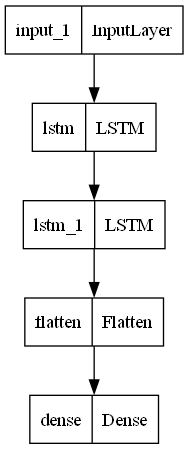

In [6]:
tensorflow.keras.utils.plot_model(model1 )

In [7]:
checkpoints = r'C:\Users\Muhammad Luqman\Desktop\OPEN_ENDED_LAB_21JZELE0444_LUQMAN\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'
OUTPUT_PATH = r'C:\Users\Muhammad Luqman\Desktop\OPEN_ENDED_LAB_21JZELE0444_LUQMAN'
FIG_PATH = os.path.sep.join([OUTPUT_PATH,"\history.png"])
JSON_PATH = os.path.sep.join([OUTPUT_PATH,"\history.json"])

In [8]:
# construct the callback to save only the *best* model to disk
# based on the validation loss
EpochCheckpoint1 = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
TrainingMonitor1=TrainingMonitor(FIG_PATH, jsonPath=JSON_PATH, startAt=start_epoch)

# construct the set of callbacks
callbacks = [EpochCheckpoint1,TrainingMonitor1]

In [9]:
# if there is no specific model checkpoint supplied, then initialize
# the network and compile the model
if model is None:
    print("[INFO] compiling model...")
    model =create_lstm()
    opt = Adam(1e-3)
    model.compile(loss= 'mae', optimizer=opt, metrics=["mae", "mape"])
# otherwise, load the checkpoint from disk
else:
    print("[INFO] loading {}...".format(model))
    model = load_model(model)

    # update the learning rate
    print("[INFO] old learning rate: {}".format(K.get_value(model.optimizer.lr)))
    K.set_value(model.optimizer.lr, 1e-4)
    print("[INFO] new learning rate: {}".format(K.get_value(model.optimizer.lr)))

[INFO] compiling model...


In [10]:
import os
path_dataset =r'C:\Users\Muhammad Luqman\Desktop\OPEN_ENDED_LAB_21JZELE0444_LUQMAN'
path_tr = os.path.join(path_dataset, '7_AEP_train.csv')
df_tr = pd.read_csv(path_tr)
train_set = df_tr.iloc[:].values
path_v = os.path.join(path_dataset, '8_AEP_validation.csv')
df_v = pd.read_csv(path_v)
validation_set = df_v.iloc[:].values 
path_te = os.path.join(path_dataset, '9_AEP_test.csv')
df_te = pd.read_csv(path_te)
test_set = df_te.iloc[:].values 

path_scaler = os.path.join(path_dataset, 'AEPscaler.pkl')
scaler         = pickle.load(open(path_scaler, 'rb'))

train_set.shape, validation_set.shape, test_set.shape

((6132, 20), (1752, 20), (876, 20))

In [11]:
time_steps=24
num_features=21

In [12]:
start = time.time()
train_X , train_y = univariate_multi_step(train_set, time_steps, target_col=0,target_len=1)
validation_X, validation_y = univariate_multi_step(validation_set, time_steps, target_col=0,target_len=1)
test_X, test_y = univariate_multi_step(test_set, time_steps, target_col=0,target_len=1)
print('Time Consumed', time.time()-start, "sec")

Time Consumed 0.04695534706115723 sec


In [13]:
epochs = 6
verbose = 1 #0
batch_size = 32
History = model.fit(train_X,
                        train_y,
                        batch_size=batch_size,   
                        epochs = epochs, 
                        validation_data = (validation_X,validation_y),
                        callbacks=callbacks,verbose = verbose)

Epoch 1/6
189/191 [============================>.] - ETA: 0s - loss: 0.0524 - mae: 0.0524 - mape: 17186966.0000
Epoch 1: val_loss improved from inf to 0.24800, saving model to C:\Users\Muhammad Luqman\Desktop\OPEN_ENDED_LAB_21JZELE0444_LUQMAN\E1-cp-0001-loss0.25.h5
191/191 [==============================] - 10s 26ms/step - loss: 0.0520 - mae: 0.0520 - mape: 17054504.0000 - val_loss: 0.2480 - val_mae: 0.2480 - val_mape: 37378172.0000
Epoch 2/6
191/191 [==============================] - ETA: 0s - loss: 0.0052 - mae: 0.0052 - mape: 2561162.7500
Epoch 2: val_loss improved from 0.24800 to 0.23176, saving model to C:\Users\Muhammad Luqman\Desktop\OPEN_ENDED_LAB_21JZELE0444_LUQMAN\E1-cp-0002-loss0.23.h5
191/191 [==============================] - 4s 22ms/step - loss: 0.0052 - mae: 0.0052 - mape: 2561162.7500 - val_loss: 0.2318 - val_mae: 0.2318 - val_mape: 24684402.0000
Epoch 3/6
189/191 [============================>.] - ETA: 0s - loss: 0.0043 - mae: 0.0043 - mape: 2174551.7500
Epoch 3: val_l

In [15]:

model = load_model(r'C:\Users\Muhammad Luqman\Desktop\OPEN_ENDED_LAB_21JZELE0444_LUQMAN\E1-cp-0006-loss0.19.h5')

y_pred_scaled   = model.predict(test_X)
y_pred          = scaler.inverse_transform(y_pred_scaled)
y_test_unscaled = scaler.inverse_transform(test_y)
# Mean Absolute Error (MAE)
MAE = np.mean(abs(y_pred - y_test_unscaled)) 
print('Mean Absolute Error (MAE): ' + str(np.round(MAE, 2)))

# Median Absolute Error (MedAE)
MEDAE = np.median(abs(y_pred - y_test_unscaled))
print('Median Absolute Error (MedAE): ' + str(np.round(MEDAE, 2)))

# Mean Squared Error (MSE)
MSE = np.square(np.subtract(y_pred, y_test_unscaled)).mean()
print('Mean Squared Error (MSE): ' + str(np.round(MSE, 2)))

# Root Mean Squarred Error (RMSE) 
RMSE = np.sqrt(np.mean(np.square(y_pred - y_test_unscaled)))
print('Root Mean Squared Error (RMSE): ' + str(np.round(RMSE, 2)))

# Mean Absolute Percentage Error (MAPE)
MAPE = np.mean((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled))) * 100
print('Mean Absolute Percentage Error (MAPE): ' + str(np.round(MAPE, 2)) + ' %')

# Median Absolute Percentage Error (MDAPE)
MDAPE = np.median((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled))) * 100
print('Median Absolute Percentage Error (MDAPE): ' + str(np.round(MDAPE, 2)) + ' %')

print('\n\ny_test_unscaled.shape= ',y_test_unscaled.shape)
print('y_pred.shape= ',y_pred.shape)

27/27 [==============================] - 1s 9ms/step
Mean Absolute Error (MAE): 0.0
Median Absolute Error (MedAE): 0.0
Mean Squared Error (MSE): 0.0
Root Mean Squared Error (RMSE): 0.0
Mean Absolute Percentage Error (MAPE): 0.34 %
Median Absolute Percentage Error (MDAPE): 0.04 %


y_test_unscaled.shape=  (851, 1)
y_pred.shape=  (851, 1)


In [16]:
checkpoints = r'C:\Users\Muhammad Luqman\Desktop\OPEN_ENDED_LAB_21JZELE0444_LUQMAN\E2-cp-{epoch:04d}-loss{val_loss:.2f}.h5'
model=r'C:\Users\Muhammad Luqman\Desktop\OPEN_ENDED_LAB_21JZELE0444_LUQMAN\E1-cp-0006-loss0.19.h5'
start_epoch= 7

In [17]:
# construct the callback to save only the *best* model to disk
# based on the validation loss
EpochCheckpoint1 = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
TrainingMonitor1=TrainingMonitor(FIG_PATH, jsonPath=JSON_PATH, startAt=start_epoch)

# construct the set of callbacks
callbacks = [EpochCheckpoint1,TrainingMonitor1]
# if there is no specific model checkpoint supplied, then initialize
# the network and compile the model
if model is None:
    print("[INFO] compiling model...")
    model = PC.build(time_steps=24, num_features=21, reg=0.0005)
    opt = Adam(1e-3)
    model.compile(loss= 'mae', optimizer=opt, metrics=["mae", "mape"])
# otherwise, load the checkpoint from disk
else:
    print("[INFO] loading {}...".format(model))
    model = load_model(model)

    # update the learning rate
    print("[INFO] old learning rate: {}".format(K.get_value(model.optimizer.lr)))
    K.set_value(model.optimizer.lr, 1e-4)
    print("[INFO] new learning rate: {}".format(K.get_value(model.optimizer.lr)))

[INFO] loading C:\Users\Muhammad Luqman\Desktop\OPEN_ENDED_LAB_21JZELE0444_LUQMAN\E1-cp-0006-loss0.19.h5...
[INFO] old learning rate: 0.0010000000474974513
[INFO] new learning rate: 9.999999747378752e-05


In [18]:
epochs = 10
verbose = 1 #0
batch_size = 32
History = model.fit(train_X,
                        train_y,
                        batch_size=batch_size,   
                        epochs = epochs, 
                        validation_data = (validation_X,validation_y),
                        callbacks=callbacks,
                        verbose = verbose)

Epoch 1/10
188/191 [============================>.] - ETA: 0s - loss: 0.0012 - mae: 0.0012 - mape: 719226.1875
Epoch 1: val_loss improved from inf to 0.19725, saving model to C:\Users\Muhammad Luqman\Desktop\OPEN_ENDED_LAB_21JZELE0444_LUQMAN\E2-cp-0001-loss0.20.h5
191/191 [==============================] - 8s 27ms/step - loss: 0.0012 - mae: 0.0012 - mape: 714007.2500 - val_loss: 0.1973 - val_mae: 0.1973 - val_mape: 16426547.0000
Epoch 2/10
189/191 [============================>.] - ETA: 0s - loss: 0.0010 - mae: 0.0010 - mape: 498343.0312
Epoch 2: val_loss improved from 0.19725 to 0.19673, saving model to C:\Users\Muhammad Luqman\Desktop\OPEN_ENDED_LAB_21JZELE0444_LUQMAN\E2-cp-0002-loss0.20.h5
191/191 [==============================] - 5s 25ms/step - loss: 0.0010 - mae: 0.0010 - mape: 499013.3750 - val_loss: 0.1967 - val_mae: 0.1967 - val_mape: 16516584.0000
Epoch 3/10
190/191 [============================>.] - ETA: 0s - loss: 0.0010 - mae: 0.0010 - mape: 527882.2500
Epoch 3: val_loss i

In [19]:

model = load_model(r'C:\Users\Muhammad Luqman\Desktop\OPEN_ENDED_LAB_21JZELE0444_LUQMAN\E2-cp-0009-loss0.19.h5')

y_pred_scaled   = model.predict(test_X)
y_pred          = scaler.inverse_transform(y_pred_scaled)
y_test_unscaled = scaler.inverse_transform(test_y)
# Mean Absolute Error (MAE)
MAE = np.mean(abs(y_pred - y_test_unscaled)) 
print('Mean Absolute Error (MAE): ' + str(np.round(MAE, 2)))

# Median Absolute Error (MedAE)
MEDAE = np.median(abs(y_pred - y_test_unscaled))
print('Median Absolute Error (MedAE): ' + str(np.round(MEDAE, 2)))

# Mean Squared Error (MSE)
MSE = np.square(np.subtract(y_pred, y_test_unscaled)).mean()
print('Mean Squared Error (MSE): ' + str(np.round(MSE, 2)))

# Root Mean Squarred Error (RMSE) 
RMSE = np.sqrt(np.mean(np.square(y_pred - y_test_unscaled)))
print('Root Mean Squared Error (RMSE): ' + str(np.round(RMSE, 2)))

# Mean Absolute Percentage Error (MAPE)
MAPE = np.mean((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled))) * 100
print('Mean Absolute Percentage Error (MAPE): ' + str(np.round(MAPE, 2)) + ' %')

# Median Absolute Percentage Error (MDAPE)
MDAPE = np.median((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled))) * 100
print('Median Absolute Percentage Error (MDAPE): ' + str(np.round(MDAPE, 2)) + ' %')

print('\n\ny_test_unscaled.shape= ',y_test_unscaled.shape)
print('y_pred.shape= ',y_pred.shape)

27/27 [==============================] - 1s 7ms/step
Mean Absolute Error (MAE): 0.0
Median Absolute Error (MedAE): 0.0
Mean Squared Error (MSE): 0.0
Root Mean Squared Error (RMSE): 0.0
Mean Absolute Percentage Error (MAPE): 0.33 %
Median Absolute Percentage Error (MDAPE): 0.04 %


y_test_unscaled.shape=  (851, 1)
y_pred.shape=  (851, 1)
